# Análisis de Ventas de Videojuegos – Tienda Online Ice  
## Planificación Estratégica para la Campaña 2017

---

## Descripción General del Proyecto

Trabajamos para **Ice**, una tienda online internacional dedicada a la venta de videojuegos. La empresa dispone de datos históricos abiertos que incluyen:

- Reseñas de usuarios y críticos especializados  
- Géneros de los videojuegos  
- Plataformas (por ejemplo, Xbox, PlayStation, PC)  
- Ventas regionales (Norteamérica, Europa, Japón y otros mercados)  
- Clasificaciones ESRB  

El dataset contiene información hasta el año 2016. Supondremos que nos encontramos en diciembre de 2016 y que debemos planificar campañas publicitarias para el año 2017.

---

## Objetivo del Análisis

El propósito principal de este proyecto es identificar patrones que permitan determinar qué factores influyen en el éxito comercial de un videojuego.  

En particular, se busca:

- Detectar plataformas con mayor potencial de crecimiento.
- Identificar géneros más rentables.
- Analizar diferencias en preferencias por región.
- Evaluar la influencia de reseñas de usuarios y críticos en las ventas.
- Probar hipótesis estadísticas relacionadas con calificaciones promedio.

Los resultados permitirán orientar la inversión publicitaria de manera estratégica para 2017.

---

## Metodología de Trabajo

El análisis se desarrollará siguiendo una estructura organizada en seis etapas:

1. Preparación de datos  
   - Limpieza y estandarización de columnas.  
   - Conversión de tipos de datos.  
   - Tratamiento de valores ausentes y casos especiales como "TBD".  
   - Cálculo de ventas globales totales por juego.  

2. Análisis exploratorio de datos  
   - Evolución de lanzamientos a lo largo del tiempo.  
   - Ciclos de vida de plataformas.  
   - Identificación de plataformas líderes y en declive.  
   - Análisis de rentabilidad por género.  
   - Relación entre reseñas y ventas.

3. Perfil de usuario por región  
   - Plataformas más populares en NA, UE y JP.  
   - Géneros predominantes por región.  
   - Influencia de las clasificaciones ESRB en las ventas regionales.

4. Pruebas de hipótesis  
   - Comparación de calificaciones promedio entre Xbox One y PC.  
   - Comparación de calificaciones promedio entre los géneros Acción y Deportes.

5. Conclusión general  
   - Síntesis de hallazgos clave.  
   - Recomendaciones estratégicas para la campaña 2017.

---

## Resultado Esperado

Al finalizar el proyecto se contará con una visión clara sobre:

- Qué plataformas presentan mayor proyección.
- Qué géneros concentran mayores ingresos.
- Cómo varían las preferencias entre regiones.
- Si existen diferencias estadísticamente significativas en calificaciones de usuarios.

Este análisis permitirá fundamentar decisiones estratégicas basadas en datos para optimizar la planificación comercial de Ice en 2017.

El objetivo del análisis es identificar qué plataformas, géneros y segmentos regionales presentan mayor potencial de retorno para orientar la inversión publicitaria en 2017. Para ello se analizarán tendencias históricas de ventas, comportamiento por región, distribución por género, clasificación ESRB y percepción de usuarios, utilizando métodos descriptivos y pruebas estadísticas.


# 1. Preparación de datos

En esta sección se realizará la limpieza y transformación del dataset con el objetivo de garantizar que la información esté en el formato adecuado para el análisis.

Las tareas principales incluyen:

- Estandarización de nombres de columnas.
- Conversión de tipos de datos.
- Identificación y tratamiento de valores ausentes.
- Manejo del valor especial "TBD".
- Cálculo de ventas globales totales por juego.


In [1]:
import pandas as pd
import numpy as np


games = pd.read_csv('/datasets/games.csv')


games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [2]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [3]:
games.describe(include='all')

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
count,16713,16715,16446.000000,16713,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000,10014,9949
unique,11559,31,NaN,12,NaN,NaN,NaN,NaN,NaN,96,8
top,Need for Speed: Most Wanted,PS2,NaN,Action,NaN,NaN,NaN,NaN,NaN,tbd,E
freq,12,2161,NaN,3369,NaN,NaN,NaN,NaN,NaN,2424,3990
mean,NaN,NaN,2006.484616,NaN,0.263377,0.145060,0.077617,0.047342,68.967679,NaN,NaN
std,NaN,NaN,5.877050,NaN,0.813604,0.503339,0.308853,0.186731,13.938165,NaN,NaN
min,NaN,NaN,1980.000000,NaN,0.000000,0.000000,0.000000,0.000000,13.000000,NaN,NaN
25%,NaN,NaN,2003.000000,NaN,0.000000,0.000000,0.000000,0.000000,60.000000,NaN,NaN
50%,NaN,NaN,2007.000000,NaN,0.080000,0.020000,0.000000,0.010000,71.000000,NaN,NaN
75%,NaN,NaN,2010.000000,NaN,0.240000,0.110000,0.040000,0.030000,79.000000,NaN,NaN


In [4]:
games.isna().mean().sort_values(ascending=False)

Critic_Score       0.513192
Rating             0.404786
User_Score         0.400897
Year_of_Release    0.016093
Name               0.000120
Genre              0.000120
Platform           0.000000
NA_sales           0.000000
EU_sales           0.000000
JP_sales           0.000000
Other_sales        0.000000
dtype: float64

### Observaciones iniciales del dataset

El dataset contiene 16,715 registros y 11 columnas. Cada fila representa un videojuego con información relacionada con su plataforma, género, ventas regionales, reseñas y clasificación ESRB.

#### Tipos de datos

- Las columnas de ventas (`NA_sales`, `EU_sales`, `JP_sales`, `Other_sales`) están correctamente almacenadas como valores numéricos (float).
- `Year_of_Release` se encuentra como tipo float64, lo cual sugiere la presencia de valores ausentes.
- `Critic_Score` está en formato numérico.
- `User_Score` está almacenada como tipo object, lo que indica la presencia de valores no numéricos (por ejemplo, "tbd").
- `Rating` es una variable categórica (object).

#### Valores ausentes

Se identifican valores ausentes principalmente en:

- `Critic_Score`: aproximadamente 51% de los registros.
- `Rating`: aproximadamente 40%.
- `User_Score`: aproximadamente 40%.
- `Year_of_Release`: aproximadamente 1.6%.

Las columnas de ventas no presentan valores ausentes, lo cual es positivo para el análisis financiero.

La alta proporción de valores faltantes en las columnas de reseñas puede deberse a:
- Juegos antiguos sin registro digital de reseñas.
- Juegos que no recibieron suficientes evaluaciones.
- Datos incompletos para 2016.
- Diferencias en cobertura de plataformas o mercados.

Además, en la columna `User_Score` aparece el valor especial "tbd" (to be determined), que deberá tratarse adecuadamente antes de realizar análisis estadísticos.

En la siguiente sección se procederá a estandarizar los nombres de las columnas y corregir los tipos de datos necesarios.


## 1.3 Estandarización de nombres de columnas

Para garantizar consistencia y facilitar el acceso a las variables, se convertirán todos los nombres de las columnas a minúsculas.

Esto permite evitar errores derivados de mayúsculas/minúsculas y mantiene coherencia en el código posterior.


In [5]:
games.columns = games.columns.str.lower()
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

Los nombres de las columnas han sido convertidos a minúsculas correctamente. 

A partir de este punto, todas las referencias a columnas en el análisis utilizarán esta convención estandarizada.


## 1.4 Conversión de tipos de datos

Algunas columnas requieren conversión para permitir análisis estadístico adecuado:

- `year_of_release` debe tratarse como variable numérica discreta (año).
- `user_score` contiene valores no numéricos como "tbd", por lo que debe limpiarse antes de convertirse a tipo numérico.
- `critic_score` debe confirmarse como variable numérica.

La correcta conversión de tipos es fundamental para realizar agrupaciones, correlaciones y pruebas de hipótesis.


In [6]:
games['year_of_release'] = pd.to_numeric(games['year_of_release'], errors='coerce')


games['user_score'] = games['user_score'].astype(str).str.lower()
games.loc[games['user_score'] == 'tbd', 'user_score'] = np.nan
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')


games['critic_score'] = pd.to_numeric(games['critic_score'], errors='coerce')

games['year_of_release'] = games['year_of_release'].astype('Int64')


games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


### Justificación de los cambios realizados

- `year_of_release`: Se convierte a tipo numérico para permitir filtrado por periodos y análisis temporal.
- `user_score`: Se reemplaza el valor "tbd" por NaN, ya que no representa una calificación válida. Posteriormente se convierte a tipo numérico para permitir cálculos de correlación y pruebas estadísticas.
- `critic_score`: Se asegura su formato numérico para análisis cuantitativo.

No se imputan valores faltantes en las columnas de puntajes, ya que hacerlo podría introducir sesgos en el análisis de correlaciones y pruebas de hipótesis.

Se convierte `year_of_release` a tipo entero (Int64) para garantizar consistencia en el análisis temporal.


## 1.5 Tratamiento de valores ausentes

Se identificaron valores ausentes principalmente en las columnas de reseñas (`critic_score`, `user_score`) y en la clasificación ESRB (`rating`).

Decisiones adoptadas:

- Las columnas `critic_score` y `user_score` no serán imputadas. La imputación podría introducir sesgos en el análisis de correlación y en las pruebas de hipótesis. Por lo tanto, los valores ausentes se conservarán como NaN y se excluirán únicamente cuando el análisis lo requiera.

- En la columna `rating`, los valores ausentes se reemplazarán por la categoría `"unknown"`. Esto permite:
  - Evitar la pérdida de registros durante agrupaciones.
  - No asumir una clasificación inexistente.
  - Analizar el peso del segmento sin clasificación dentro del mercado.


In [7]:
games['rating'] = games['rating'].fillna('unknown')

games['rating'].value_counts()

unknown    6766
E          3990
T          2961
M          1563
E10+       1420
EC            8
K-A           3
RP            3
AO            1
Name: rating, dtype: int64

La categoría `"unknown"` representa juegos cuya clasificación ESRB no está disponible en el dataset. 

Esto permite mantener la integridad de los datos sin asumir información que no está documentada.


## 1.6 Cálculo de ventas globales

Para evaluar el desempeño comercial total de cada videojuego, se calculará una nueva variable que represente la suma de ventas en todas las regiones disponibles:

- Norteamérica (`na_sales`)
- Europa (`eu_sales`)
- Japón (`jp_sales`)
- Otros mercados (`other_sales`)

Esta variable permitirá realizar comparaciones globales entre plataformas, géneros y periodos.


In [8]:
sales_columns = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']

games['total_sales'] = games[sales_columns].sum(axis=1)

games[['name', 'platform', 'total_sales']].head()

,name,platform,total_sales
0,Wii Sports,Wii,82.54
1,Super Mario Bros.,NES,40.24
2,Mario Kart Wii,Wii,35.52
3,Wii Sports Resort,Wii,32.77
4,Pokemon Red/Pokemon Blue,GB,31.38


# 2. Análisis exploratorio de datos

En esta sección se analizará la evolución histórica del mercado de videojuegos con el objetivo de identificar patrones estructurales.

Se estudiará:

- Evolución de lanzamientos por año.
- Ciclos de vida de plataformas.
- Tendencias de ventas.
- Géneros más rentables.
- Relación entre reseñas y desempeño comercial.

El objetivo es determinar qué periodo resulta más representativo para proyectar estrategias hacia 2017.

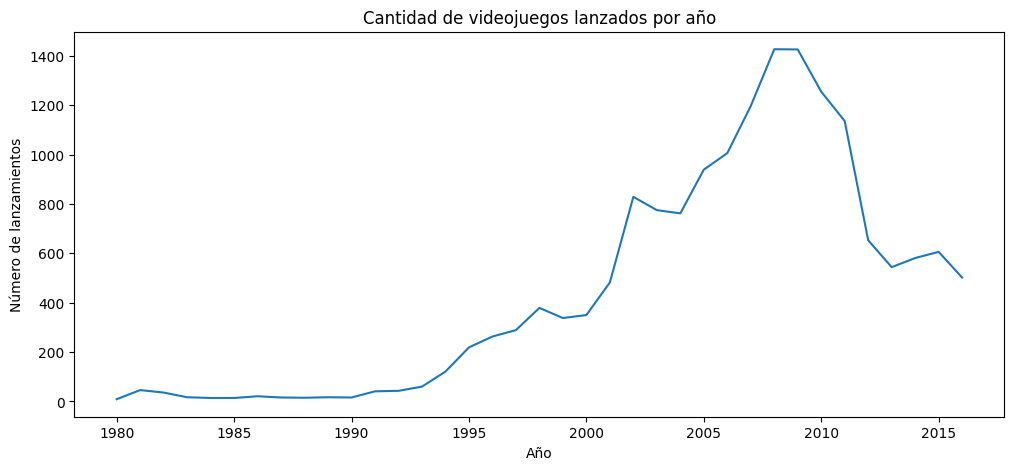

In [9]:
import matplotlib.pyplot as plt
from scipy import stats as st
games_by_year = games.groupby('year_of_release')['name'].count()

games_by_year.plot(figsize=(12,5))
plt.title('Cantidad de videojuegos lanzados por año')
plt.xlabel('Año')
plt.ylabel('Número de lanzamientos')
plt.show()

### Evolución de lanzamientos por año

El número de videojuegos lanzados muestra un crecimiento sostenido desde mediados de la década de 1990, con una aceleración significativa a partir del año 2000.

El punto máximo de lanzamientos se observa alrededor de 2008–2009, periodo que coincide con la madurez de plataformas como PlayStation 3, Xbox 360 y Wii.

A partir de 2011 se evidencia una disminución considerable en el número de lanzamientos anuales, lo que puede indicar:

- Transición generacional de consolas.
- Consolidación del mercado.
- Cambios en modelos de distribución (digitalización).
- Mayor concentración en títulos de alto presupuesto.

Se observa una disminución en 2016; sin embargo, esta caída puede estar influenciada por registros incompletos del año en el dataset. Por ello, las tendencias se interpretan con cautela y se prioriza la señal estructural del ciclo de consolas más que variaciones puntuales.

## 2.2 Evolución de ventas por plataforma

Para comprender la dinámica del mercado, se analizarán las ventas totales acumuladas por plataforma.

El objetivo es:

- Identificar plataformas históricamente dominantes.
- Detectar ciclos de crecimiento y declive.
- Determinar cuánto tiempo suele durar el ciclo de vida comercial de una consola.
- Evaluar qué plataformas podrían ser relevantes para proyectar 2017.

In [10]:
platform_sales = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

platform_sales.head(10)

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64

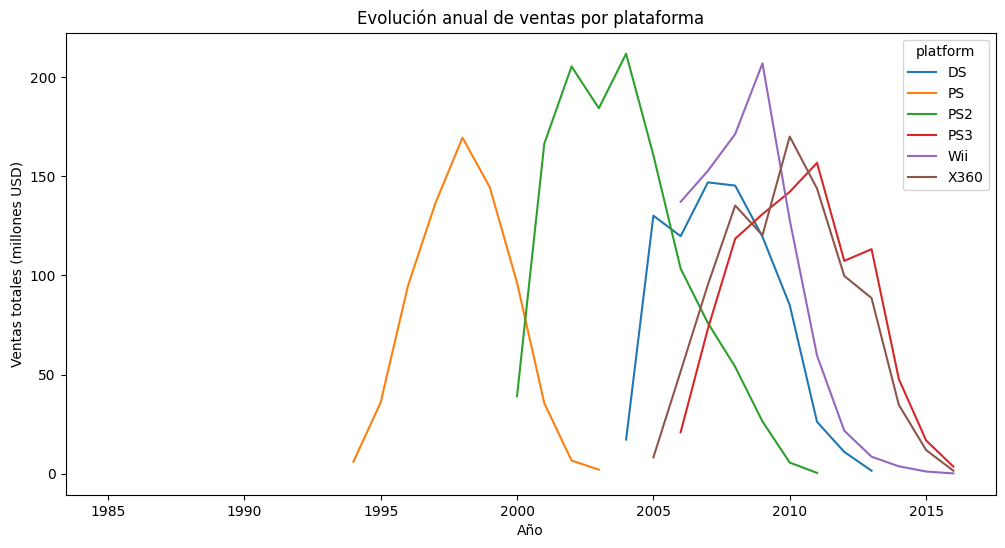

In [11]:
top_platforms = platform_sales.head(6).index

platform_year = games[games['platform'].isin(top_platforms)].pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

platform_year.plot(figsize=(12,6))
plt.title('Evolución anual de ventas por plataforma')
plt.xlabel('Año')
plt.ylabel('Ventas totales (millones USD)')
plt.show()

## 2.3 Selección del período relevante para proyección 2017

Dado que el objetivo es planificar estrategias publicitarias para 2017, no resulta apropiado utilizar datos históricos muy antiguos, ya que el mercado de videojuegos está fuertemente condicionado por los ciclos generacionales de las consolas.

El análisis previo muestra que:

- Las generaciones PS3 y Xbox 360 entran en declive a partir de 2012.
- La generación actual (PS4 y Xbox One) comienza a consolidarse alrededor de 2013.
- El ciclo de vida comercial fuerte de una consola suele durar entre 5 y 7 años.

Por lo tanto, se selecciona el período 2013–2016 como representativo del mercado moderno para proyectar decisiones hacia 2017.

In [12]:
relevant_games = games[games['year_of_release'] >= 2013].copy()

relevant_games['year_of_release'].min(), relevant_games['year_of_release'].max()

(2013, 2016)

## 2.4 Plataformas líderes en el período 2013–2016

Una vez definido el período relevante para proyectar 2017, se analizan las ventas totales por plataforma dentro del rango 2013–2016.

El objetivo es identificar:

- Qué plataformas concentran mayores ingresos actuales.
- Qué consolas mantienen relevancia comercial.
- Dónde podría ser más eficiente invertir presupuesto publicitario en 2017.

In [13]:
relevant_platform_sales = (
    relevant_games
    .groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

relevant_platform_sales

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64

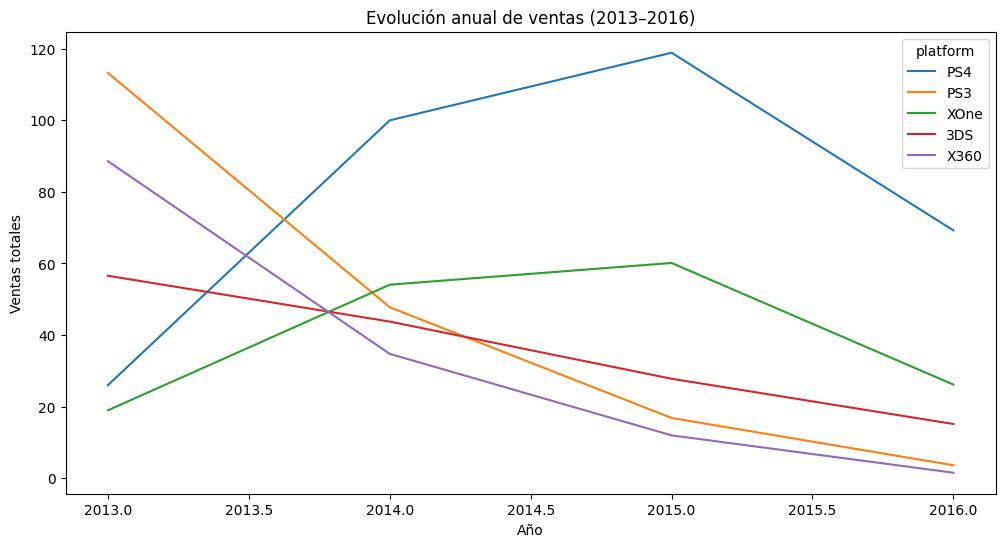

In [14]:
relevant_pivot = relevant_games.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

# seleccionar solo las 5 plataformas principales
top5 = relevant_platform_sales.head(5).index

relevant_pivot[top5].plot(figsize=(12,6))
plt.title('Evolución anual de ventas (2013–2016)')
plt.xlabel('Año')
plt.ylabel('Ventas totales')
plt.show()

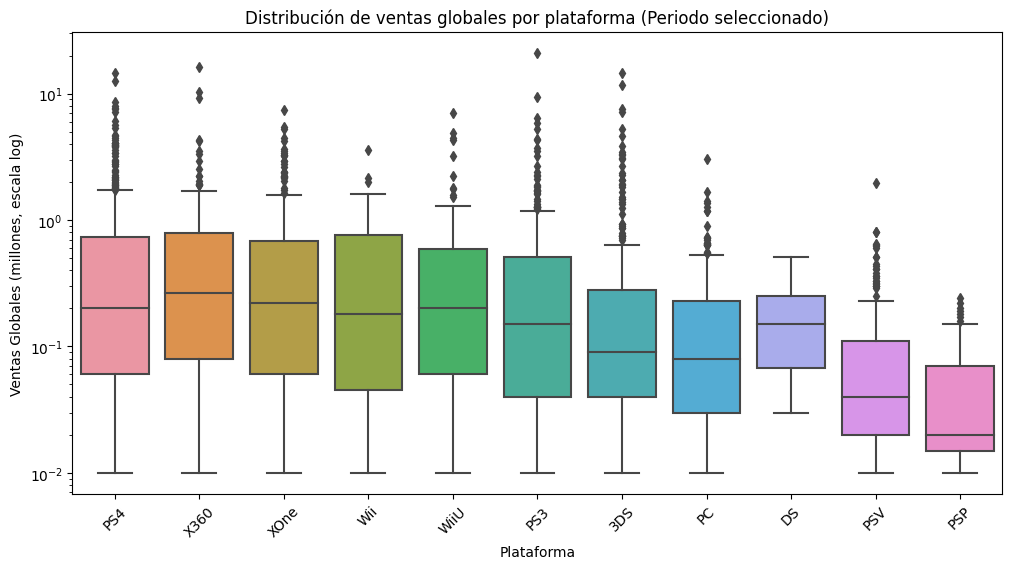

In [15]:
platform_order = (
    relevant_games
    .groupby('platform')['total_sales']
    .mean()
    .sort_values(ascending=False)
    .index
)
import seaborn as sns
plt.figure(figsize=(12,6))

sns.boxplot(
    data=relevant_games,
    x='platform',
    y='total_sales',
    order= platform_order
)

plt.yscale('log')

plt.title('Distribución de ventas globales por plataforma (Periodo seleccionado)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Globales (millones, escala log)')
plt.xticks(rotation=45)

plt.show()


Para analizar el comportamiento reciente del mercado de videojuegos, se seleccionó el periodo 2013–2016. Limitar el análisis a un intervalo menor a cinco años permite capturar mejor las dinámicas actuales del mercado, ya que la industria de los videojuegos presenta cambios tecnológicos rápidos y ciclos de vida relativamente cortos para las plataformas.

#### Evolución anual de ventas

El gráfico de evolución anual muestra el cambio en las ventas totales de las principales plataformas durante el periodo analizado.

Se observa que **PS4 experimenta un crecimiento fuerte desde 2013 hasta alcanzar su punto máximo en 2015**, lo que refleja la consolidación de la nueva generación de consolas. La disminución observada en 2016 probablemente se debe a datos incompletos para ese año y no necesariamente a un cambio estructural en el mercado.

**Xbox One presenta un patrón similar**, con crecimiento sostenido hasta 2015 seguido de una caída en 2016. Esto sugiere que ambas consolas forman parte de la misma generación tecnológica y siguen ciclos de adopción comparables.

En contraste, **PS3 y Xbox 360 muestran una disminución constante en sus ventas**, lo que indica claramente su transición hacia la fase final de su ciclo de vida como plataformas de generación anterior.

Por su parte, **Nintendo 3DS también muestra una tendencia descendente**, aunque más gradual, reflejando la disminución progresiva del interés en plataformas portátiles de esa generación.

En conjunto, el gráfico evidencia un **cambio generacional en el mercado**, donde las plataformas más recientes comienzan a dominar mientras las anteriores pierden relevancia.

#### Distribución de ventas por plataforma

Para complementar el análisis temporal, se construyó un **gráfico de cajas (boxplot)** que muestra la distribución de ventas globales por juego dentro de cada plataforma durante el periodo seleccionado. Debido a la fuerte asimetría en los datos de ventas, se utilizó una **escala logarítmica** para facilitar la visualización de las medianas y la dispersión.

El gráfico revela que:

- La mayoría de los juegos registran **ventas relativamente bajas**, concentradas en los rangos inferiores.
- Existe un número reducido de **outliers con ventas muy altas**, lo que indica que el mercado depende fuertemente de unos pocos títulos exitosos.
- Plataformas como **PS4, X360 y XOne presentan medianas relativamente más altas**, lo que sugiere un mayor rendimiento típico por juego.
- En contraste, plataformas como **PSV y PSP muestran medianas considerablemente más bajas**, indicando menor desempeño comercial promedio.

Además, la presencia de numerosos valores atípicos sugiere que el éxito comercial dentro de cada plataforma es **altamente variable**, dependiendo en gran medida de títulos individuales de gran impacto.

#### Conclusión del análisis

El análisis conjunto de ambas visualizaciones permite entender mejor la dinámica del mercado en el periodo analizado. El gráfico de evolución anual muestra el **cambio generacional hacia nuevas consolas**, mientras que el boxplot revela que el mercado está **fuertemente concentrado en unos pocos títulos de alto rendimiento**.


## 2.5 Distribución y rentabilidad por género (2013–2016)

En esta sección se analizarán las ventas globales por género dentro del período relevante (2013–2016).

El objetivo es identificar:

- Qué géneros generan mayores ingresos.
- Qué segmentos podrían ser estratégicamente más rentables para campañas publicitarias en 2017.

In [16]:
genre_sales = (
    relevant_games
    .groupby('genre')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

genre_sales

genre
Action          321.87
Shooter         232.98
Sports          150.65
Role-Playing    145.89
Misc             62.82
Platform         42.63
Racing           39.89
Fighting         35.31
Adventure        23.64
Simulation       21.76
Strategy         10.08
Puzzle            3.17
Name: total_sales, dtype: float64

## 2.6 Distribución de ventas por género

El análisis anterior mostró las ventas totales acumuladas por género en el período 2013–2016. Sin embargo, las ventas totales pueden estar influenciadas por dos factores distintos:

- Un gran número de títulos con ventas moderadas.
- Un pequeño número de títulos con ventas extremadamente altas (blockbusters).

Desde una perspectiva estratégica, esta diferencia es fundamental.

Para la planificación publicitaria en 2017 es importante entender si un género:

- Presenta ventas consistentes en la mayoría de sus títulos.
- Depende fuertemente de unos pocos éxitos excepcionales.
- Muestra alta variabilidad y, por tanto, mayor riesgo comercial.

Por esta razón, se analizará la distribución de ventas mediante diagramas de caja (boxplots), lo que permitirá observar medianas, dispersión y presencia de valores atípicos.

<Figure size 1400x600 with 0 Axes>

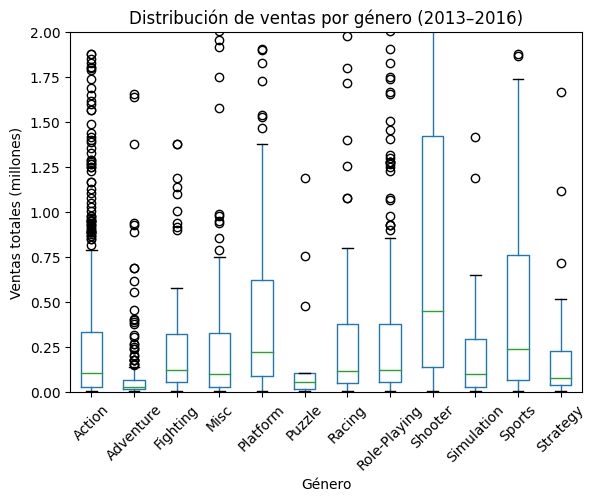

In [17]:
plt.figure(figsize=(14,6))

relevant_games.boxplot(
    column='total_sales',
    by='genre',
    grid=False,
    rot=45
)

plt.ylim(0, 2)  # límite del eje Y para reducir el impacto de outliers

plt.title('Distribución de ventas por género (2013–2016)')
plt.suptitle('')
plt.xlabel('Género')
plt.ylabel('Ventas totales (millones)')
plt.show()

### Distribución de ventas por género (2013–2016)

Para complementar el análisis de ventas totales por género, se construyó un diagrama de cajas que permite observar la distribución de ventas por juego dentro de cada género durante el periodo analizado.

Con el fin de facilitar la comparación entre géneros, se estableció un límite en el eje Y para reducir el impacto visual de los valores atípicos extremadamente altos.

A partir del gráfico se observan varios patrones relevantes:

**Concentración de ventas en pocos títulos**

En la mayoría de los géneros, la mediana de ventas por juego es relativamente baja. Esto indica que la mayoría de los títulos presentan ventas moderadas o reducidas. Sin embargo, se observan numerosos valores atípicos que alcanzan niveles de ventas mucho mayores, lo que sugiere que el mercado está fuertemente influenciado por un número limitado de juegos muy exitosos.

**Géneros con mayor volumen potencial**

Géneros como **Action, Shooter y Sports** muestran una mayor dispersión y la presencia de varios valores altos. Esto indica que, aunque muchos juegos presentan ventas moderadas, estos géneros también concentran algunos de los títulos más exitosos del mercado.

**Géneros con menor desempeño relativo**

Otros géneros como **Puzzle, Strategy y Simulation** presentan distribuciones más concentradas en valores bajos y menos valores extremos, lo que sugiere un menor impacto comercial en comparación con los géneros más populares.

**Interpretación general**

El análisis del boxplot revela que el desempeño comercial de los juegos varía considerablemente dentro de cada género. En general, el éxito en el mercado de videojuegos no depende únicamente del género, sino también de títulos específicos que logran ventas significativamente superiores al promedio.

### Síntesis estratégica hasta el momento

A través de un embudo estratégico, el análisis ha permitido estructurar la toma de decisiones en tres niveles:

1. **Contexto estructural:**  
   Se identificaron las plataformas con mayor relevancia en el período 2013–2016, destacando principalmente PS4 y Xbox One como las más sólidas para proyectar inversión en 2017.

2. **Oportunidad de mercado por categoría:**  
   Dentro de estas plataformas dominantes, se analizaron los géneros con mayor volumen de ventas, identificando Action y Shooter como los segmentos líderes en términos de ingresos.

3. **Selección táctica de títulos:**  
   El análisis de distribución mostró que el mercado está altamente concentrado en pocos títulos de alto rendimiento, lo que indica que la estrategia no debe enfocarse únicamente en géneros, sino en juegos específicos con fuerte potencial comercial.

En consecuencia, la estrategia publicitaria para 2017 debe construirse combinando:
- Plataformas dominantes,
- Géneros líderes,
- Y títulos con alta probabilidad de desempeño superior.

### 2.7 Relación entre ventas, reseñas y comportamiento de juegos multiplataforma

Antes de proceder al análisis de perfiles regionales, se analiza la relación entre el desempeño comercial de los juegos y sus reseñas, tanto de críticos como de usuarios. Además, se examina el comportamiento de los juegos lanzados en múltiples plataformas.

#### Correlación entre ventas y reseñas de críticos

Para evaluar la relación entre las ventas globales y las reseñas de críticos, se analiza la correlación entre las variables **critic_score** y **total_sales**, así como su visualización mediante un gráfico de dispersión.

Este análisis permite identificar si existe una relación entre la valoración profesional de un juego y su desempeño comercial. En particular, se busca observar si los juegos con mejores calificaciones de críticos tienden a alcanzar mayores niveles de ventas.

#### Correlación entre ventas y reseñas de usuarios

De manera similar, se examina la relación entre las ventas globales y las calificaciones otorgadas por los usuarios mediante la correlación entre **user_score** y **total_sales**.

Este análisis permite evaluar si la percepción del público está asociada con el éxito comercial de los juegos o si las ventas dependen en mayor medida de otros factores, como marketing, popularidad de franquicias o presencia en plataformas específicas.

#### Comportamiento de juegos multiplataforma

Finalmente, se analiza el comportamiento de los juegos que fueron lanzados en **más de una plataforma**. Para ello, se identifican los títulos que aparecen en múltiples plataformas dentro del dataset y se examina cómo varían sus ventas según la plataforma en la que se publican.

Este análisis permite determinar si ciertos juegos logran un mejor desempeño comercial en determinadas plataformas y si existen plataformas que tienden a generar mayores ventas para títulos multiplataforma.

#### Objetivo del análisis

En conjunto, este apartado permite comprender mejor cómo influyen las reseñas y la elección de plataforma en el desempeño comercial de los videojuegos, proporcionando información relevante para interpretar el comportamiento del mercado antes de analizar las diferencias regionales.

In [18]:
critic_corr_data = relevant_games[['critic_score', 'total_sales']].dropna()

print(critic_corr_data.head())
print()
print('Número de filas para el análisis:', len(critic_corr_data))

    critic_score  total_sales
16          97.0        21.05
23          97.0        16.27
42          97.0        12.62
60          73.0        10.24
69          71.0         9.36

Número de filas para el análisis: 991


In [19]:
critic_correlation = critic_corr_data['critic_score'].corr(critic_corr_data['total_sales'])

print('Correlación entre critic_score y total_sales:', critic_correlation)

Correlación entre critic_score y total_sales: 0.3136995151027371


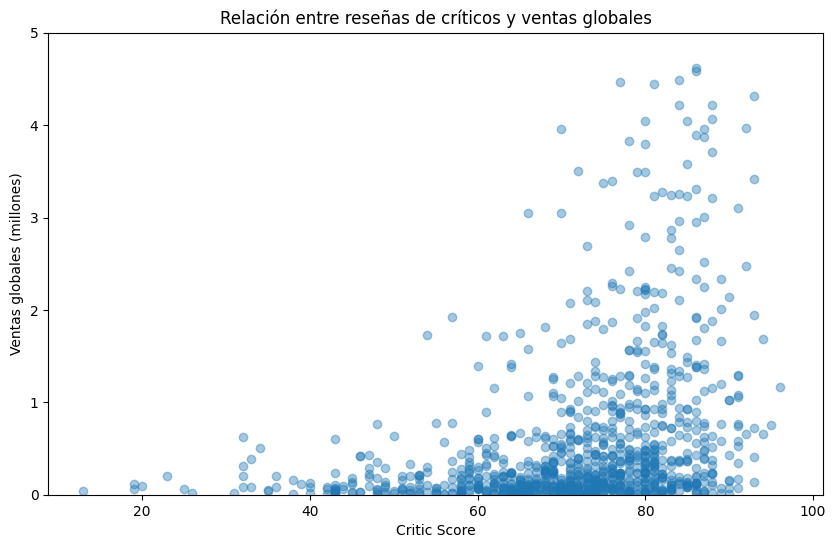

In [20]:
plt.figure(figsize=(10, 6))
plt.ylim(0, 5)

plt.scatter(
    critic_corr_data['critic_score'],
    critic_corr_data['total_sales'],
    alpha=0.4
)

plt.title('Relación entre reseñas de críticos y ventas globales')
plt.xlabel('Critic Score')
plt.ylabel('Ventas globales (millones)')

plt.show()

In [21]:
user_corr_data = relevant_games[['user_score', 'total_sales']].dropna()

print(user_corr_data.head())
print()
print('Número de filas para el análisis:', len(user_corr_data))

    user_score  total_sales
16         8.2        21.05
23         8.1        16.27
42         8.3        12.62
60         2.6        10.24
69         2.6         9.36

Número de filas para el análisis: 1192


In [22]:
user_correlation = user_corr_data['user_score'].corr(user_corr_data['total_sales'])

print('Correlación entre user_score y total_sales:', user_correlation)

Correlación entre user_score y total_sales: -0.0026078133545982744


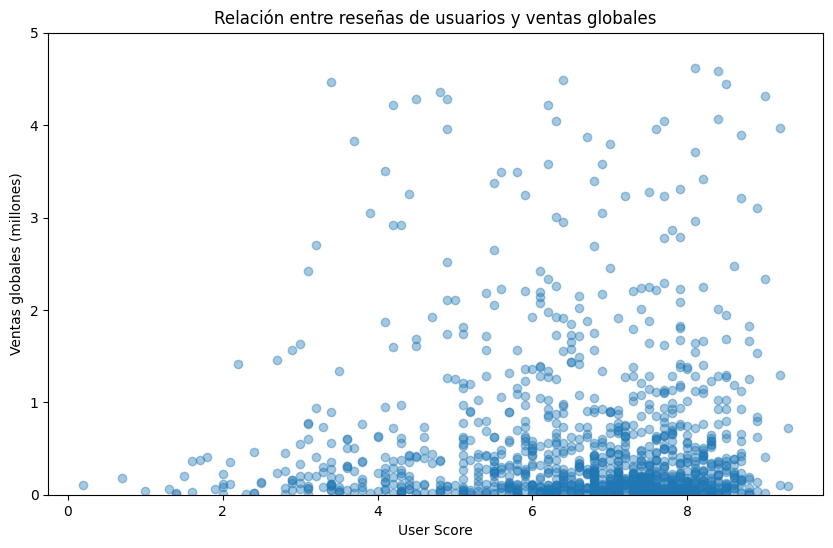

In [23]:
plt.figure(figsize=(10, 6))
plt.ylim(0, 5)

plt.scatter(
    user_corr_data['user_score'],
    user_corr_data['total_sales'],
    alpha=0.4
)

plt.title('Relación entre reseñas de usuarios y ventas globales')
plt.xlabel('User Score')
plt.ylabel('Ventas globales (millones)')

plt.show()

In [24]:
print('Correlación ventas vs critic_score:', critic_correlation)
print('Correlación ventas vs user_score:', user_correlation)

Correlación ventas vs critic_score: 0.3136995151027371
Correlación ventas vs user_score: -0.0026078133545982744


In [25]:
platforms_per_game = relevant_games.groupby('name')['platform'].nunique()

multi_platform_titles = platforms_per_game[platforms_per_game > 1].index

print('Cantidad de juegos multiplataforma:', len(multi_platform_titles))

Cantidad de juegos multiplataforma: 473


In [26]:
multi_platform_games = relevant_games[relevant_games['name'].isin(multi_platform_titles)]

print(multi_platform_games[['name', 'platform', 'total_sales']].head(10))

                              name platform  total_sales
16              Grand Theft Auto V      PS3        21.05
23              Grand Theft Auto V     X360        16.27
31       Call of Duty: Black Ops 3      PS4        14.63
42              Grand Theft Auto V      PS4        12.62
60            Call of Duty: Ghosts     X360        10.24
69            Call of Duty: Ghosts      PS3         9.36
72                       Minecraft     X360         9.18
77                         FIFA 16      PS4         8.58
87    Star Wars Battlefront (2015)      PS4         7.98
92  Call of Duty: Advanced Warfare      PS4         7.66


In [27]:
multi_platform_sales = (
    multi_platform_games
    .groupby('platform')['total_sales']
    .mean()
    .sort_values(ascending=False)
)

print(multi_platform_sales)

platform
PS4     0.884335
X360    0.747111
Wii     0.618636
XOne    0.603080
PS3     0.594621
3DS     0.330484
WiiU    0.321286
PC      0.208231
DS      0.192500
PSV     0.134643
PSP     0.102857
Name: total_sales, dtype: float64


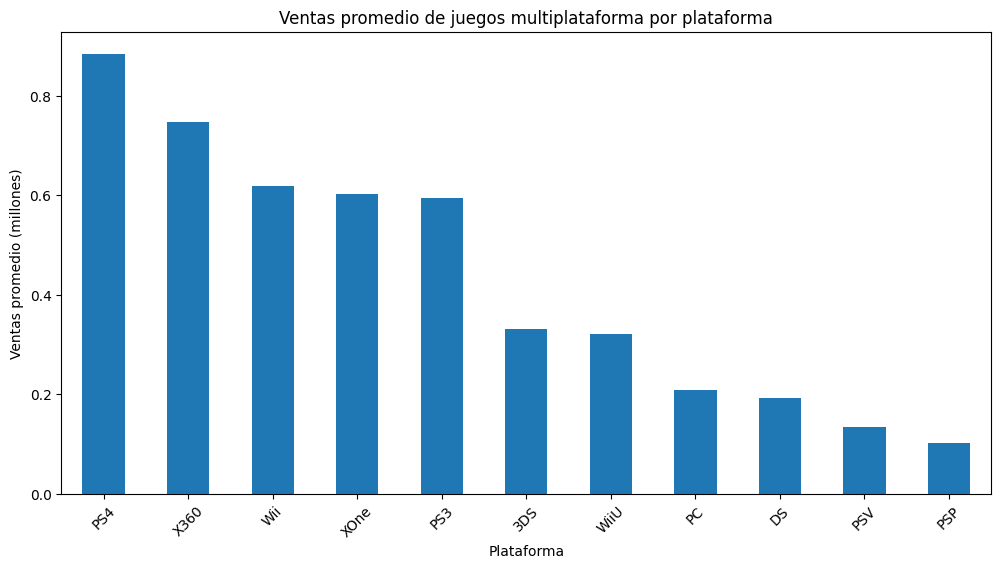

In [28]:
plt.figure(figsize=(12, 6))

multi_platform_sales.plot(kind='bar')

plt.title('Ventas promedio de juegos multiplataforma por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas promedio (millones)')
plt.xticks(rotation=45)

plt.show()

In [29]:
multi_platform_examples = (
    multi_platform_games
    .groupby(['name', 'platform'])['total_sales']
    .sum()
    .reset_index()
    .sort_values(by=['name', 'total_sales'], ascending=[True, False])
)

multi_platform_examples.head(20)

,name,platform,total_sales
0,Frozen: Olaf's Quest,3DS,0.59
1,Frozen: Olaf's Quest,DS,0.51
2,2014 FIFA World Cup Brazil,PS3,0.61
3,2014 FIFA World Cup Brazil,X360,0.43
4,3rd Super Robot Wars Z Jigoku Hen,PS3,0.23
5,3rd Super Robot Wars Z Jigoku Hen,PSV,0.19
7,3rd Super Robot Wars Z: Tengoku-Hen,PSV,0.19
6,3rd Super Robot Wars Z: Tengoku-Hen,PS3,0.15
8,7 Days to Die,PS4,0.14
9,7 Days to Die,XOne,0.05


## 2.7 Influencia de las reseñas y comportamiento de los juegos multiplataforma

### Objetivo del análisis

En este apartado se analiza la relación entre las reseñas de críticos y usuarios con las ventas globales de los videojuegos. Además, se examina cómo se comportan los títulos que se lanzan en múltiples plataformas, con el fin de comprender mejor qué factores influyen en el desempeño comercial de los juegos.

Este análisis complementa la evaluación de plataformas y géneros realizada previamente, permitiendo identificar si la recepción crítica, la opinión de los usuarios o la elección de plataforma están asociadas con mayores niveles de ventas.

---

# Relación entre reseñas de críticos y ventas

Para evaluar esta relación se calculó la correlación entre **critic_score** y **total_sales**.

El coeficiente obtenido fue:

**Correlación ventas vs critic_score = 0.31**

Esto indica una **correlación positiva moderada** entre las reseñas de críticos y las ventas globales.

En el gráfico de dispersión se observa que:

- Los juegos con **calificaciones altas de críticos (70–90)** tienden a concentrar un mayor número de títulos con ventas elevadas.
- Sin embargo, también existen juegos con altas calificaciones que no alcanzan grandes ventas.
- La relación, por lo tanto, **no es determinística**, pero sí muestra una tendencia general positiva.

Esto sugiere que una buena recepción crítica **puede contribuir al éxito comercial**, aunque no lo garantiza por sí sola.

---

# Relación entre reseñas de usuarios y ventas

También se analizó la relación entre **user_score** y **total_sales**.

El coeficiente obtenido fue:

**Correlación ventas vs user_score = -0.0026**

Este valor es prácticamente **cero**, lo que indica **ausencia de correlación significativa** entre la calificación de los usuarios y las ventas globales.

El gráfico de dispersión confirma este resultado:

- Juegos con puntuaciones de usuario altas y bajas aparecen distribuidos en niveles de ventas similares.
- No se observa una tendencia clara que indique que mejores reseñas de usuarios se traduzcan en mayores ventas.

Esto sugiere que, en el conjunto de datos analizado, **la percepción de los usuarios no tiene un impacto claro en el volumen de ventas globales**.

Una posible explicación es que muchas ventas ocurren **antes de que las reseñas de usuarios se consoliden**, o que factores como marketing, franquicia o plataforma influyan más fuertemente en la decisión de compra.

---

# Comparación entre ambos tipos de reseñas

Al comparar ambos resultados se observa que:

| Tipo de reseña | Correlación con ventas |
|----------------|-----------------------|
| Críticos | 0.31 |
| Usuarios | -0.0026 |

Esto indica que:

- Las **reseñas de críticos tienen mayor relación con las ventas** que las reseñas de usuarios.
- La recepción crítica puede influir en la visibilidad y credibilidad de un juego en el mercado.

---

# Comportamiento de los juegos multiplataforma

También se analizó el comportamiento de los juegos lanzados en **más de una plataforma**.

Se identificaron:

**473 títulos multiplataforma** dentro del período analizado.

El análisis de ventas promedio por plataforma para estos títulos muestra el siguiente patrón:

| Plataforma | Ventas promedio (millones) |
|------------|----------------------------|
| PS4 | 0.88 |
| X360 | 0.75 |
| Wii | 0.62 |
| XOne | 0.60 |
| PS3 | 0.59 |
| 3DS | 0.33 |
| WiiU | 0.32 |
| PC | 0.21 |
| DS | 0.19 |
| PSV | 0.13 |
| PSP | 0.10 |

Los resultados indican que:

- Las **consolas principales (PS4, Xbox 360, Xbox One y PS3)** presentan mayores ventas promedio para títulos multiplataforma.
- Las **consolas portátiles y plataformas más pequeñas** muestran ventas promedio considerablemente menores.
- La **PS4 lidera claramente en rendimiento promedio**, lo que refuerza su posición como una de las plataformas más fuertes durante el periodo analizado.

Además, al observar ejemplos específicos se puede ver que **un mismo juego puede tener resultados muy diferentes dependiendo de la plataforma en la que se publique**.

Por ejemplo:

- *Grand Theft Auto V* muestra ventas mucho mayores en consolas principales.
- Otros títulos presentan ventas más modestas en plataformas secundarias.

Esto sugiere que **la plataforma de lanzamiento es un factor importante en el desempeño comercial de un juego**, incluso cuando se trata del mismo título.

---

# Conclusión del análisis

Los resultados permiten extraer varias conclusiones clave sobre los factores asociados con el éxito comercial de los videojuegos:

1. Las **reseñas de críticos muestran una relación moderada con las ventas**, lo que sugiere que la recepción crítica puede influir en el desempeño comercial de los juegos.

2. Las **reseñas de usuarios no presentan una relación clara con las ventas**, lo que indica que la percepción de los jugadores no necesariamente se traduce en mayores ingresos.

3. Los **juegos multiplataforma tienden a vender más en consolas principales**, especialmente en PS4 y Xbox 360.

En conjunto, estos resultados muestran que el éxito de un videojuego depende de una **combinación de factores**, entre los que destacan la plataforma de lanzamiento y, en menor medida, la recepción crítica.

Este análisis proporciona información relevante para comprender el comportamiento del mercado antes de examinar las diferencias regionales en las siguientes secciones del estudio.

# 3. Perfil de usuario por región

El comportamiento del mercado de videojuegos puede variar significativamente entre regiones.

Para planificar campañas publicitarias efectivas en 2017, se analizarán por separado las siguientes regiones:

- Norteamérica (NA)
- Europa (EU)
- Japón (JP)

Se evaluará:

- Las cinco plataformas principales por región.
- Los cinco géneros más relevantes.
- El posible impacto de las clasificaciones ESRB en cada mercado.

El objetivo es identificar diferencias estructurales que puedan afectar la asignación de presupuesto publicitario.

## 3.1 Plataformas líderes por región (2013–2016)

Aunque el análisis global permite identificar tendencias generales, el comportamiento del mercado puede variar significativamente entre regiones.

En esta sección se identifican las cinco plataformas con mayores ventas en:

- Norteamérica
- Europa
- Japón

El objetivo es determinar si la dominancia observada a nivel global se mantiene en cada mercado o si existen diferencias estructurales que deban influir en la estrategia publicitaria para 2017.

In [30]:
regions = {
    'na_sales': 'Norteamérica',
    'eu_sales': 'Europa',
    'jp_sales': 'Japón'
}

for col, region_name in regions.items():
    top_platforms_region = (
        relevant_games
        .groupby('platform')[col]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )
    
    print(f"\nTop 5 plataformas en {region_name}:")
    print(top_platforms_region)


Top 5 plataformas en Norteamérica:
platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64

Top 5 plataformas en Europa:
platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64

Top 5 plataformas en Japón:
platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64


Los resultados muestran que no existe una plataforma dominante universal. Mientras PS4 lidera en Norteamérica y Europa, Japón presenta una estructura distinta con predominancia de 3DS.

Esto implica que la asignación de presupuesto publicitario debe realizarse de manera regionalizada y no global.

## 3.2 Géneros líderes por región (2013–2016)

Dado que las plataformas muestran comportamientos distintos según la región, es necesario evaluar si las preferencias por género también varían geográficamente.

En esta sección se analizarán los cinco géneros con mayores ventas en cada región para identificar:

- Diferencias culturales en el consumo de videojuegos.
- Segmentos con mayor potencial de inversión publicitaria por mercado.
- Oportunidades específicas para campañas regionalizadas en 2017.

In [31]:
for col, region_name in regions.items():
    top_genres_region = (
        relevant_games
        .groupby('genre')[col]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )
    
    print(f"\nTop 5 géneros en {region_name}:")
    print(top_genres_region)


Top 5 géneros en Norteamérica:
genre
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64

Top 5 géneros en Europa:
genre
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64

Top 5 géneros en Japón:
genre
Role-Playing    51.04
Action          40.49
Misc             9.20
Fighting         7.65
Shooter          6.61
Name: jp_sales, dtype: float64


### Hallazgos regionales sobre preferencias de género

El análisis muestra diferencias claras entre mercados occidentales y el mercado japonés.

**Norteamérica y Europa** presentan patrones similares:
- Action y Shooter lideran en ventas.
- Sports mantiene una posición sólida.
- El consumo está orientado hacia experiencias competitivas y de alto ritmo.

En contraste, **Japón muestra un perfil distinto**:
- Role-Playing es el género dominante.
- Shooter pierde relevancia significativa.
- Fighting y otros géneros tradicionales japoneses mantienen presencia.

---

### Implicaciones estratégicas para 2017

Una estrategia publicitaria global uniforme no sería eficiente.

- En Norteamérica y Europa, la inversión debería priorizar títulos de Action y Shooter en plataformas dominantes.
- En Japón, la estrategia debe enfocarse en Role-Playing y Action, particularmente en plataformas con fuerte presencia local.

La segmentación regional es clave para maximizar retorno de inversión publicitaria.

Las preferencias por género varían significativamente entre regiones, lo que refuerza la necesidad de segmentación cultural en la estrategia 2017.

## 3.3 Impacto de la clasificación ESRB por región (2013–2016)

Además de plataforma y género, la clasificación ESRB puede influir en el comportamiento del consumidor.

En esta sección se analizará la distribución de ventas por categoría de edad (Rating) en cada región con el objetivo de determinar:

- Si ciertos mercados consumen más contenido adulto.
- Si existen diferencias culturales en la preferencia por clasificación.
- Si la estrategia publicitaria debe adaptarse según el perfil demográfico predominante.

In [32]:
for col, region_name in regions.items():
    rating_region = (
        relevant_games
        .groupby('rating')[col]
        .sum()
        .sort_values(ascending=False)
    )
    
    print(f"\nVentas por clasificación ESRB en {region_name}:")
    print(rating_region)


Ventas por clasificación ESRB en Norteamérica:
rating
M          165.21
unknown     89.42
E           79.05
E10+        54.24
T           49.79
Name: na_sales, dtype: float64

Ventas por clasificación ESRB en Europa:
rating
M          145.32
E           83.36
unknown     78.91
E10+        42.69
T           41.95
Name: eu_sales, dtype: float64

Ventas por clasificación ESRB en Japón:
rating
unknown    85.05
T          20.59
E          15.14
M          14.11
E10+        5.89
Name: jp_sales, dtype: float64


### Hallazgos sobre clasificación ESRB por región

El análisis de ventas por clasificación ESRB revela diferencias relevantes entre los mercados occidentales y Japón.

**Norteamérica y Europa** presentan patrones similares:
- La categoría **M (Mature)** lidera en ventas.
- El contenido orientado a público adulto tiene fuerte presencia.
- Esto es consistente con la dominancia de géneros como Action y Shooter en estas regiones.

Este comportamiento sugiere que los mercados occidentales muestran mayor afinidad hacia experiencias intensas y competitivas, lo cual debe considerarse en el tono y enfoque de las campañas publicitarias.

En contraste, **Japón muestra un patrón distinto**:
- La categoría "unknown" tiene un peso significativo, lo cual puede explicarse por diferencias en sistemas de clasificación (CERO vs ESRB).
- Entre las categorías definidas, **T (Teen)** supera a **M (Mature)**.
- El contenido altamente adulto tiene menor peso relativo en comparación con Norteamérica y Europa.

---

### Implicaciones estratégicas

La clasificación por edad refuerza la necesidad de segmentación regional:

- En **Norteamérica y Europa**, las campañas pueden enfocarse en títulos orientados a público adulto, especialmente en géneros como Action y Shooter.
- En **Japón**, la estrategia debería alinearse más con títulos de Role-Playing y clasificaciones menos orientadas a contenido extremo.

En conjunto, los resultados confirman que la estrategia publicitaria para 2017 debe adaptarse no solo por plataforma y género, sino también por perfil demográfico regional.

En Japón, la categoría `unknown` representa una proporción considerable de ventas. Esto puede deberse a ausencia de clasificación ESRB en ciertos títulos o diferencias en sistemas de clasificación regional.

Por ello, las conclusiones sobre preferencias etarias en Japón deben interpretarse con cautela.

# 4. Prueba de hipótesis

En esta sección se evaluarán dos hipótesis relacionadas con las calificaciones de usuarios (`user_score`).  
Para cada caso se definirá:

- Hipótesis nula (H₀) y alternativa (H₁)
- Nivel de significancia (α)
- Prueba estadística apropiada
- Interpretación del p-valor y conclusión

**Nivel de significancia:** se usará α = 0.05, un umbral común en análisis estadístico para controlar la probabilidad de error tipo I (rechazar H₀ cuando es verdadera).

Dado que se comparan medias entre **dos grupos independientes**, se utilizará una **prueba t de Welch** (`ttest_ind` con `equal_var=False`), ya que no asume varianzas iguales entre grupos y es robusta cuando los tamaños muestrales difieren.

## 4.1 Hipótesis 1: Xbox One vs PC

**Pregunta:** ¿Las calificaciones promedio de usuarios para Xbox One y PC son las mismas?

- **H₀ (hipótesis nula):** la media de `user_score` en Xbox One es igual a la media de `user_score` en PC.  
  \[
  \mu_{XOne} = \mu_{PC}
  \]

- **H₁ (hipótesis alternativa):** las medias son diferentes.  
  \[
  \mu_{XOne} \neq \mu_{PC}
  \]

Se aplicará una prueba t de Welch para dos muestras independientes.

In [33]:
from scipy import stats as st

alpha = 0.05

xone_scores = relevant_games.loc[relevant_games['platform'] == 'XOne', 'user_score'].dropna()
pc_scores   = relevant_games.loc[relevant_games['platform'] == 'PC', 'user_score'].dropna()

results = st.ttest_ind(xone_scores, pc_scores, equal_var=False)

print("p-value:", results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos H0: hay evidencia de diferencia entre las medias.")
else:
    print("No rechazamos H0: no hay evidencia suficiente de diferencia entre las medias.")

p-value: 0.14759594013430463
No rechazamos H0: no hay evidencia suficiente de diferencia entre las medias.


Se utilizó la prueba t de Welch para muestras independientes debido a que no se asume igualdad de varianzas entre grupos y los tamaños de muestra pueden diferir.

## 4.2 Hipótesis 2: Action vs Sports

**Pregunta:** ¿Las calificaciones promedio de usuarios para los géneros Acción y Deportes son diferentes?

- **H₀ (hipótesis nula):** la media de `user_score` en Acción es igual a la media de `user_score` en Deportes.  
  \[
  \mu_{Action} = \mu_{Sports}
  \]

- **H₁ (hipótesis alternativa):** las medias son diferentes.  
  \[
  \mu_{Action} \neq \mu_{Sports}
  \]

Se aplicará una prueba t de Welch para dos muestras independientes.

In [34]:
alpha = 0.05

action_scores = relevant_games.loc[relevant_games['genre'] == 'Action', 'user_score'].dropna()
sports_scores = relevant_games.loc[relevant_games['genre'] == 'Sports', 'user_score'].dropna()

results = st.ttest_ind(action_scores, sports_scores, equal_var=False)

print("p-value:", results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos H0: hay evidencia de diferencia entre las medias.")
else:
    print("No rechazamos H0: no hay evidencia suficiente de diferencia entre las medias.")

p-value: 1.4460039700704315e-20
Rechazamos H0: hay evidencia de diferencia entre las medias.


El resultado indica que la percepción de los usuarios varía según el género, lo que sugiere que el tipo de contenido influye más en la valoración que la plataforma en la que se publica.

## Interpretación de resultados

### Hipótesis 1: Xbox One vs PC

El valor p obtenido fue **0.1476**, superior al nivel de significancia α = 0.05.

Dado que p-value ≥ α, **no se rechaza la hipótesis nula**.

Esto indica que no existe evidencia estadísticamente significativa para afirmar que las calificaciones promedio de usuarios entre Xbox One y PC sean diferentes en el período analizado.

En términos prácticos, las percepciones de usuarios en ambas plataformas son comparables.

---

### Hipótesis 2: Action vs Sports

El valor p obtenido fue **1.446 × 10⁻²⁰**, considerablemente menor que α = 0.05.

Dado que p-value < α, **se rechaza la hipótesis nula**.

Existe evidencia estadísticamente significativa de que las calificaciones promedio de usuarios para los géneros Action y Sports son diferentes.

Esto sugiere que la percepción del usuario varía entre estos géneros, lo cual podría influir en decisiones estratégicas relacionadas con posicionamiento y segmentación de campañas.

# 5. Conclusión General

El análisis realizado permitió identificar patrones estructurales del mercado de videojuegos con el fin de orientar la estrategia publicitaria para 2017 basada en evidencia cuantitativa.

---

# 1. Contexto estructural del mercado

El análisis temporal mostró que el mercado alcanzó su punto máximo de lanzamientos entre 2008 y 2010, seguido de una fase de ajuste.

Para construir una proyección relevante hacia 2017, se delimitó el período **2013–2016**, correspondiente al ciclo activo de consolas de última generación.

Durante este período se observó que:

- **PS4 y Xbox One** emergen como plataformas dominantes en Norteamérica y Europa.
- Consolas de generación anterior como **PS3 y Xbox 360** muestran una tendencia clara de declive.
- En **Japón**, plataformas portátiles como **Nintendo 3DS** mantienen una posición dominante.

Estos resultados indican que la inversión publicitaria debe concentrarse en **plataformas activas dentro de su ciclo de vida**, adaptando además la estrategia según la estructura regional del mercado.

---

# 2. Géneros y concentración del mercado

El análisis de ventas por género mostró que **Action y Shooter** lideran el mercado global durante el período analizado.

Sin embargo, el análisis de distribución mediante diagramas de caja evidenció que:

- La **mediana de ventas por juego es baja en la mayoría de los géneros**.
- Existen **valores atípicos (outliers)** que concentran una gran parte de las ventas totales.

Este patrón confirma que el mercado está **altamente concentrado en un número reducido de títulos exitosos (blockbusters)**, más que en el rendimiento promedio de un género.

Por lo tanto, una estrategia publicitaria eficaz no debe basarse únicamente en seleccionar géneros populares, sino en **identificar títulos con alto potencial comercial dentro de esos géneros**.

---

# 3. Influencia de reseñas y comportamiento de juegos multiplataforma

El análisis de correlación permitió evaluar la relación entre las reseñas y el desempeño comercial de los videojuegos.

Los resultados muestran que:

- Existe una **correlación positiva moderada entre las reseñas de críticos y las ventas globales** (≈ 0.31).
- Las **reseñas de usuarios no muestran una relación significativa con las ventas** (≈ 0).

Esto sugiere que la recepción crítica puede tener cierta influencia en el éxito comercial de un juego, mientras que las calificaciones de usuarios no presentan una relación clara con el volumen de ventas.

Adicionalmente, se analizó el comportamiento de **juegos multiplataforma**, identificándose **473 títulos lanzados en más de una plataforma**.

El análisis de ventas promedio muestra que:

- Las **consolas principales (PS4, Xbox 360, Xbox One y PS3)** presentan los mayores niveles de ventas promedio para títulos multiplataforma.
- Plataformas portátiles y sistemas con menor base instalada muestran **ventas considerablemente más bajas**.

Además, se observó que **un mismo título puede presentar resultados muy diferentes dependiendo de la plataforma**, lo que indica que la elección de plataforma es un factor relevante en el desempeño comercial.

---

# 4. Segmentación regional

El comportamiento del mercado varía significativamente entre regiones:

- **Norteamérica y Europa** muestran preferencia por los géneros **Action y Shooter**, además de mayor consumo de contenido clasificado como **Mature**.
- **Japón** presenta un perfil distinto, con predominancia del género **Role-Playing** y mayor relevancia de **plataformas portátiles**.

Estos resultados indican que una estrategia publicitaria uniforme a nivel global sería ineficiente. La asignación de presupuesto debe realizarse con **segmentación regional**, considerando preferencias culturales, plataformas dominantes y tipo de contenido.

---

# 5. Resultados de las pruebas de hipótesis

Las pruebas estadísticas aportan validación adicional al análisis descriptivo realizado:

- No se encontró evidencia significativa de diferencia en las **calificaciones promedio entre Xbox One y PC**.
- Sí se encontró una **diferencia estadísticamente significativa entre las calificaciones promedio de los géneros Action y Sports**.

Esto sugiere que la percepción del usuario está más influenciada por el **tipo de contenido del juego** que por la plataforma en la que se publica.

---

# 6. Implicaciones estratégicas para 2017

A partir del análisis estructural del mercado, la segmentación regional y la validación estadística, la estrategia óptima para 2017 debería:

- Priorizar **plataformas activas dentro de su ciclo de vida**, diferenciando la estrategia según la región.
- Enfocar la inversión publicitaria en **géneros líderes en cada mercado**.
- Identificar **títulos con alto potencial de ventas dentro de esos géneros**, dado el alto nivel de concentración del mercado.
- Considerar la **recepción crítica como un indicador relevante del desempeño comercial potencial**.
- Aprovechar el lanzamiento **multiplataforma en consolas con mayor base de usuarios**, donde el impacto comercial es mayor.

---

# Conclusión

El mercado de videojuegos se caracteriza por una **alta concentración de ventas en títulos específicos dentro de plataformas y géneros dominantes**.

El análisis muestra que el éxito comercial depende de la interacción de varios factores:  
plataforma de lanzamiento, género del juego, recepción crítica y características regionales del mercado.

La combinación de **análisis descriptivo, análisis de correlación, segmentación regional y pruebas estadísticas** permite construir una estrategia publicitaria fundamentada en datos, reduciendo el riesgo de decisiones basadas únicamente en intuición.